# BNCC Machine Learning Workshop: Classification

Pada notebook ini, kita akan mempelajari alur kerja machine learning untuk masalah classification secara end-to-end. Tujuannya adalah membangun model yang dapat membedakan SMS biasa (`ham`) dan SMS spam (`spam`).

Alur notebook dibuat mirip dengan notebook regression: mulai dari memahami dataset, membersihkan data, preprocessing, training model, evaluasi, membuat pipeline, inference, sampai eksperimen model lain.


In [1]:
print("Welcome to BNCC Machine Learning Workshop - Classification")

Welcome to BNCC Machine Learning Workshop - Classification


Sebelum membangun model, kita perlu mengetahui sumber data yang digunakan. Dataset pada notebook ini berisi kumpulan pesan SMS yang sudah diberi label `ham` atau `spam`.


Link Dataset: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

In [2]:
import re
import string

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Memuat Dataset

Pada bagian ini, kita mulai memuat file dataset ke dalam pandas DataFrame. Setelah data berhasil dibaca, tampilkan beberapa baris pertama dan memastikan kolom-kolomnya sudah sesuai.

In [3]:
# TODO: lengkapi kode berikut untuk memuat dataset

df = pd.read_csv("../dataset/spam.csv", encoding="latin-1")

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


Cek struktur dataset: jumlah baris, nama kolom, tipe data, dan apakah ada missing value. Tahap ini membantu kita memastikan dataset sudah terbaca dengan benar sebelum masuk ke visualisasi dan modeling.

In [4]:
# TODO: lengkapi kode berikut untuk melihat struktur dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [5]:
extra_cols = ["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"]

df[df[extra_cols].notna().any(axis=1)][["v1", "v2"] + extra_cols].head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
95,spam,Your free ringtone is waiting to be collected....,PO Box 5249,"MK17 92H. 450Ppw 16""",NaN
281,ham,\Wen u miss someone,the person is definitely special for u..... B...,why to miss them,"just Keep-in-touch\"" gdeve.."""
444,ham,\HEY HEY WERETHE MONKEESPEOPLE SAY WE MONKEYAR...,HOWU DOIN? FOUNDURSELF A JOBYET SAUSAGE?LOVE ...,NaN,NaN
671,spam,SMS. ac sun0819 posts HELLO:\You seem cool,"wanted to say hi. HI!!!\"" Stop? Send STOP to ...",NaN,NaN
710,ham,Height of Confidence: All the Aeronautics prof...,"this wont even start........ Datz confidence..""",NaN,NaN


Beberapa pesan pada dataset terpecah ke kolom `Unnamed` karena format CSV yang kurang rapi. Agar isi SMS tetap utuh, kita gabungkan kolom `v2`, `Unnamed: 2`, `Unnamed: 3`, dan `Unnamed: 4` menjadi satu kolom baru bernama `message`.

Nilai kosong diisi dengan string kosong terlebih dahulu, lalu hasil gabungan dirapikan dengan menghapus spasi berlebih.

In [6]:
# TODO: gabungkan banyak kolom menjadi 1 kolom message

message_columns = ["v2", "Unnamed: 2", "Unnamed: 3", "Unnamed: 4"]

df["message"] = (
    df[message_columns]
    .fillna("")
    .agg(" ".join, axis=1)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

Informasi Fitur Dataset:

1. `label` = kelas SMS, berisi `ham` untuk SMS biasa dan `spam` untuk SMS spam.
2. `message` = isi pesan SMS dalam bentuk teks.


In [7]:
# TODO: ambil dan rename kolom menjadi label dan message

df = df[["v1", "message"]]

df.columns = ["label", "message"]

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Missing value perlu dicek sebelum modeling karena data kosong bisa membuat proses preprocessing atau training gagal. Hitung jumlah nilai kosong pada setiap kolom.


In [8]:
# TODO: cek jumlah data kosong di setiap kolom

df.isna().sum()

label      0
message    0
dtype: int64

Data duplikat bisa membuat model melihat pesan yang sama lebih dari sekali. Cek jumlah data duplikat, lalu hapus jika ditemukan agar evaluasi model lebih adil.


In [9]:
duplicated_data = df[df.duplicated(keep=False)].sort_values(by=["label", "message"])

duplicated_data.head()

,label,message
1372,ham,1) Go to write msg 2) Put on Dictionary mode 3...
2162,ham,1) Go to write msg 2) Put on Dictionary mode 3...
2343,ham,1) Go to write msg 2) Put on Dictionary mode 3...
1469,ham,7 wonders in My WORLD 7th You 6th Ur style 5th...
1778,ham,7 wonders in My WORLD 7th You 6th Ur style 5th...


In [10]:
# TODO: cek dan hapus data duplikat jika ada

duplicate_count = df.duplicated().sum()

print(f"Jumlah data duplikat: {duplicate_count}")
print(f"Jumlah data sebelum drop duplicate: {len(df)}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Jumlah data setelah drop duplicate: {len(df)}")

Jumlah data duplikat: 414
Jumlah data sebelum drop duplicate: 5572
Jumlah data setelah drop duplicate: 5158


Lihat distribusi label untuk mengetahui berapa banyak SMS biasa dan SMS spam. Pada classification, distribusi kelas penting karena dataset yang tidak seimbang bisa membuat accuracy terlihat tinggi walaupun model kurang baik dalam mendeteksi kelas minoritas.


In [11]:
# TODO: cek distribusi label ham dan spam

label_summary = (
    df["label"]
    .value_counts()
    .reset_index()
)

label_summary.columns = ["label", "jumlah"]

label_summary["persentase"] = (
    label_summary["jumlah"] / label_summary["jumlah"].sum() * 100
).round(2)

label_summary

,label,jumlah,persentase
0,ham,4516,87.55
1,spam,642,12.45


## EDA (Exploratory Data Analysis)

Visualisasi distribusi label membantu kita melihat apakah jumlah SMS `ham` dan `spam` seimbang. Jika jumlah salah satu kelas jauh lebih besar, evaluasi perlu memperhatikan precision, recall, dan F1-score, bukan hanya accuracy.


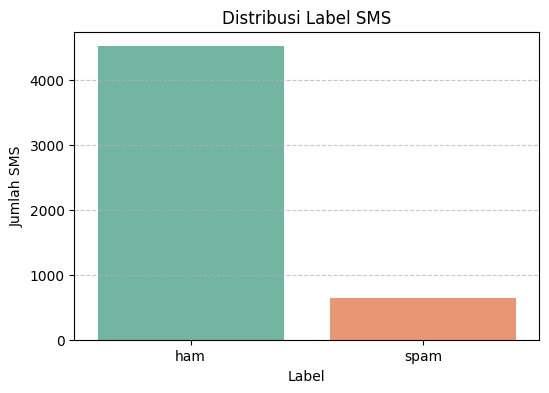

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="label", hue="label", palette="Set2", legend=False)
plt.title("Distribusi Label SMS")
plt.xlabel("Label")
plt.ylabel("Jumlah SMS")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

Panjang pesan bisa menjadi salah satu sinyal sederhana untuk membedakan spam dan ham. Pada cell ini, kita membuat fitur `message_length`, lalu membandingkan distribusinya untuk setiap label.


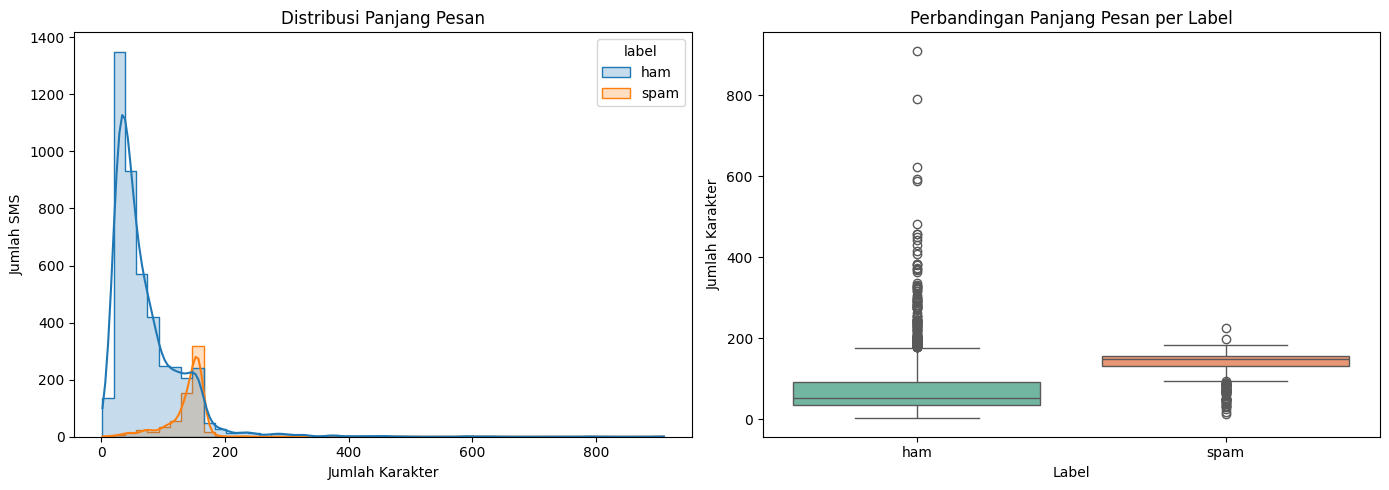

In [13]:
df["message_length"] = df["message"].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df,
    x="message_length",
    hue="label",
    bins=50,
    kde=True,
    element="step",
    ax=axes[0]
)
axes[0].set_title("Distribusi Panjang Pesan")
axes[0].set_xlabel("Jumlah Karakter")
axes[0].set_ylabel("Jumlah SMS")

sns.boxplot(
    data=df,
    x="label",
    y="message_length",
    hue="label",
    palette="Set2",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Perbandingan Panjang Pesan per Label")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Jumlah Karakter")

plt.tight_layout()
plt.show()

In [14]:
# ringkasan panjang pesan per label

message_length_summary = (
    df.groupby("label")["message_length"]
    .describe()
    .round(2)
    .reset_index()
)

message_length_summary

,label,count,mean,std,min,25%,50%,75%,max
0,ham,4516.0,70.93,56.58,2.0,34.0,53.0,91.0,910.0
1,spam,642.0,137.87,30.07,13.0,132.0,148.5,157.0,224.0


## Membersihkan Data

Pada tahap cleaning, kita gunakan salinan dataset agar data asli tetap aman. Isi pesan akan dinormalisasi dengan lowercase, penghapusan punctuation, dan perapihan whitespace.

Untuk target classification, kita tetap menggunakan label asli yaitu `ham` dan `spam` agar hasil evaluasi lebih mudah dibaca oleh peserta.


In [15]:
# TODO: copy dataframe terlebih dahulu supaya dataframe asli tidak berubah

df_clean = df.copy()

In [16]:
# TODO: buat fungsi sederhana untuk membersihkan teks

def clean_text(text):
    text = str(text).lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text


df_clean["message_clean"] = df_clean["message"].apply(clean_text)

df_clean[["label", "message", "message_clean"]].head()

,label,message,message_clean
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


## Stratified Train-Test Split

Sebelum membagi data, tentukan dulu mana kolom yang menjadi fitur dan mana kolom yang menjadi target. Pada kasus classification ini, fitur adalah teks pesan, sedangkan target adalah label `ham` atau `spam`.

Kita menggunakan `stratify=y` agar proporsi `ham` dan `spam` tetap mirip pada training set dan test set.


In [17]:
# TODO: pisahkan fitur dan target

X = df_clean["message_clean"]
y = df_clean["label"]

In [18]:
from sklearn.model_selection import train_test_split

# TODO: lakukan splitting dan tentukan jumlah data yang akan di jadikan testing

UKURAN_TEST_SET = 0.2

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=UKURAN_TEST_SET,
    random_state=42,
    stratify=y
)

print(f"Jumlah data training: {len(X_train)}")
print(f"Jumlah data testing: {len(X_test)}")

print("\nDistribusi target pada training set:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nDistribusi target pada test set:")
print(y_test.value_counts(normalize=True).sort_index())

Jumlah data training: 4126
Jumlah data testing: 1032

Distribusi target pada training set:
label
ham     0.875424
spam    0.124576
Name: proportion, dtype: float64

Distribusi target pada test set:
label
ham     0.875969
spam    0.124031
Name: proportion, dtype: float64


## Representasi Teks dengan TF-IDF

TF-IDF digunakan untuk mengubah teks menjadi angka agar bisa diproses oleh model machine learning. Setiap kata/token yang dipilih akan menjadi satu fitur dalam bentuk vektor.

Pada `TfidfVectorizer`, `stop_words="english"` berarti kata-kata umum dalam bahasa Inggris seperti `the`, `is`, `and`, atau `to` akan diabaikan karena biasanya tidak membawa banyak informasi untuk klasifikasi.

`max_features=3000` membatasi ukuran vocabulary maksimal menjadi 3000 token. Karena setiap token di vocabulary menjadi satu dimensi fitur, maka hasil TF-IDF akan memiliki maksimal 3000 dimensi fitur.

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TODO: ubah teks menjadi fitur numerik menggunakan TF-IDF

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=3000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Shape X_train sebelum TF-IDF: {X_train.shape}")
print(f"Shape X_train setelah TF-IDF: {X_train_tfidf.shape}")
print(f"Shape X_test setelah TF-IDF: {X_test_tfidf.shape}")

Shape X_train sebelum TF-IDF: (4126,)
Shape X_train setelah TF-IDF: (4126, 3000)
Shape X_test setelah TF-IDF: (1032, 3000)


Untuk melihat token apa saja yang dipelajari oleh TF-IDF, kita bisa mengambil beberapa contoh token dari vocabulary.

Token yang muncul tidak selalu berupa kata biasa. Pada dataset SMS, token bisa berupa kata, angka, kode, atau nomor telepon karena semuanya muncul di dalam pesan. Ini membantu kita memahami bentuk fitur teks yang nantinya digunakan oleh model.

In [20]:
# NOTE: jalankan kode ini beberapa kali untuk melihat semua kata/token yang di pelajari oleh TF-IDF

import numpy as np

feature_names = tfidf.get_feature_names_out()

np.random.choice(feature_names, size=50, replace=False)

array(['jus', 'logo', 'mac', 'ey', 'ufind', 'ta', 'key', 'nyc', 'ignore',
       'profit', 'miss', 'american', 'yay', 'south', 'big', 'charles',
       'ad', 'watever', '3030', 'online', 'snogs', 'seat', 'canary',
       'sunday', 'advice', 'polyph', 'babes', 'saucy', 'colour',
       'boyfriend', 'searching', 'divorce', 'partner', 'beautiful',
       'shared', 'ni8', 'correct', 'aunts', 'rally', 'match',
       'wwwtextcompcom', 'normally', 'white', 'fault', '150p', 'sing',
       'offers', 'hmm', 'intro', 'anniversary'], dtype=object)

## Training menggunakan Logistic Regression

Setelah teks selesai diubah menjadi angka, kita bisa melatih model classification. Logistic Regression sering digunakan sebagai baseline untuk classification karena sederhana, cepat, dan hasilnya mudah dibandingkan dengan model lain.


In [21]:
from sklearn.linear_model import LogisticRegression

# TODO: lakukan training model menggunakan logistic regression

model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

## Evaluasi Model Logistic Regression

Evaluasi pada training set digunakan untuk melihat seberapa baik model mempelajari data yang digunakan saat training.

Nilai ini nantinya perlu dibandingkan dengan performa pada test set. Jika performa training jauh lebih baik daripada test, model bisa jadi mengalami overfitting, yaitu terlalu menyesuaikan diri dengan data training tetapi kurang baik saat menghadapi pesan baru.

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# TODO: buatkan fungsi untuk menghitung metriks klasifikasi

def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label="spam")
    recall = recall_score(y_true, y_pred, pos_label="spam")
    f1 = f1_score(y_true, y_pred, pos_label="spam")

    metrics = {
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-score": round(f1, 4)
    }

    return metrics

In [23]:
# TODO: hitung metriks model pada training set

y_train_pred = model.predict(X_train_tfidf)

training_metrics = calculate_metrics(y_train, y_train_pred)

print(f"Training metrics: {training_metrics}")

Training metrics: {'Accuracy': 0.968, 'Precision': 0.9923, 'Recall': 0.749, 'F1-score': 0.8537}


Pada classification, beberapa model juga bisa menghasilkan probability atau peluang untuk setiap kelas. Pada contoh ini, `spam_probability` menunjukkan seberapa besar peluang sebuah pesan dianggap sebagai `spam` oleh model.

`predict_proba()` menghasilkan probability untuk setiap kelas yang dipelajari model. Karena kita ingin mengambil peluang kelas `spam`, kita cari posisi kelas `spam` dari `model.classes_`, lalu mengambil probability pada kolom tersebut. Jika nilainya semakin mendekati 1, model semakin yakin pesan tersebut adalah spam.


In [24]:
# TODO: lakukan prediksi pada test set

TAMPILKAN_PREDIKSI = 10

y_pred = model.predict(X_test_tfidf)

spam_class_index = list(model.classes_).index("spam")
y_pred_proba = model.predict_proba(X_test_tfidf)[:, spam_class_index]

prediction_preview = pd.DataFrame({
    "message": X_test.iloc[:TAMPILKAN_PREDIKSI].values,
    "actual": y_test.iloc[:TAMPILKAN_PREDIKSI].values,
    "predicted": y_pred[:TAMPILKAN_PREDIKSI],
    "spam_probability": y_pred_proba[:TAMPILKAN_PREDIKSI].round(4)
})

prediction_preview

,message,actual,predicted,spam_probability
0,i to am looking forward to all the sex cuddlin...,ham,ham,0.1191
1,i asked sen to come chennai and search for job,ham,ham,0.0343
2,kkwhen will you give treat,ham,ham,0.0657
3,may b approve panalambut it should have more p...,ham,ham,0.0806
4,one of best dialogue in cute reltnship wen i d...,ham,ham,0.0395
5,am watching house ûò very entertaining ûò am...,ham,ham,0.0523
6,you please give us connection today itself bef...,ham,ham,0.0617
7,kkcongratulation,ham,ham,0.0806
8,kay since we are out already,ham,ham,0.0806
9,so ìll be submitting da project tmr rite,ham,ham,0.0348


Setelah melihat performa pada training set, evaluasi juga perlu dilakukan pada test set.

Test set berisi pesan yang tidak digunakan saat training, sehingga hasil evaluasi ini lebih menggambarkan kemampuan model pada data baru. Bandingkan metrik training dan test untuk melihat apakah model cukup general atau mulai menunjukkan tanda overfitting.

In [25]:
# TODO: hitung metriks model pada test set

test_metrics = calculate_metrics(y_test, y_pred)

print(f"Test metrics: {test_metrics}")

Test metrics: {'Accuracy': 0.9583, 'Precision': 0.9885, 'Recall': 0.6719, 'F1-score': 0.8}


Confusion matrix menunjukkan detail kesalahan model. Untuk kasus spam detection, false positive berarti SMS biasa salah dianggap spam, sedangkan false negative berarti SMS spam lolos sebagai SMS biasa.


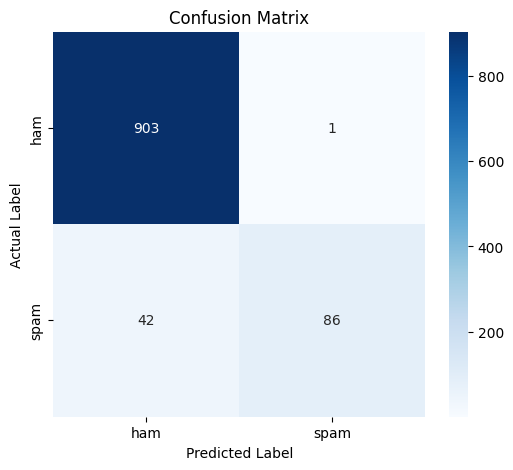

In [26]:
from sklearn.metrics import confusion_matrix

# TODO: hitung confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["ham", "spam"],
    yticklabels=["ham", "spam"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

## Membuat Pipeline versi ColumnTransformer

Preprocessing sebelumnya dibuat secara manual agar setiap langkah lebih mudah dipahami. Namun dalam workflow machine learning yang lebih rapi, preprocessing dan model sebaiknya dibungkus dalam pipeline.

Karena dataset classification ini hanya memakai satu kolom teks, `ColumnTransformer` digunakan untuk menerapkan pipeline teks pada kolom `message`. Dengan cara ini, model bisa menerima data mentah dan seluruh proses cleaning, TF-IDF, dan training berjalan dalam satu alur.


In [27]:
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

In [28]:
class TextCleaner(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.iloc[:, 0]

        return pd.Series(X).apply(clean_text).to_numpy()


class SpamClassificationModel:
    def __init__(self, model=None, vectorizer=None):
        if model is None:
            model = LogisticRegression(max_iter=1000, random_state=42)

        if vectorizer is None:
            vectorizer = TfidfVectorizer(stop_words="english", max_features=3000)

        self.model = model
        self.vectorizer = vectorizer
        self.text_feature = "message"

        text_pipeline = Pipeline([
            ("cleaner", TextCleaner()),
            ("tfidf", self.vectorizer)
        ])

        preprocessor = ColumnTransformer([
            ("text", text_pipeline, self.text_feature)
        ])

        self.pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", self.model)
        ])

    def train(self, X_train, y_train):
        self.pipeline.fit(X_train, y_train)
        return self

    def evaluate(self, X, y):
        y_pred = self.pipeline.predict(X)

        return calculate_metrics(y, y_pred)

    def predict(self, X):
        return self.pipeline.predict(X)

    def predict_proba(self, X):
        if hasattr(self.pipeline, "predict_proba"):
            return self.pipeline.predict_proba(X)

        raise AttributeError("Model ini tidak memiliki method predict_proba().")

    def tune(
        self,
        X_train,
        y_train,
        param_grid,
        cv=5,
        scoring=None,
        n_jobs=-1
    ):
        if scoring is None:
            scoring = make_scorer(f1_score, pos_label="spam")

        search = GridSearchCV(
            estimator=self.pipeline,
            param_grid=param_grid,
            cv=cv,
            scoring=scoring,
            n_jobs=n_jobs
        )

        search.fit(X_train, y_train)
        self.pipeline = search.best_estimator_

        return {
            "best_params": search.best_params_,
            "best_score": search.best_score_
        }

Pada versi pipeline, kita mulai lagi dari pesan mentah agar seluruh preprocessing dilakukan di dalam pipeline. Ini lebih aman untuk eksperimen karena cleaning dan TF-IDF selalu ikut terbawa saat training, evaluation, tuning, dan inference.


In [29]:
df_pipeline = pd.read_csv("../dataset/spam.csv", encoding="latin-1")

# gabungkan potongan pesan dari kolom Unnamed jika ada
message_columns = ["v2", "Unnamed: 2", "Unnamed: 3", "Unnamed: 4"]

df_pipeline["message"] = (
    df_pipeline[message_columns]
    .fillna("")
    .agg(" ".join, axis=1)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# ambil kolom yang dibutuhkan
df_pipeline = df_pipeline[["v1", "message"]]
df_pipeline.columns = ["label", "message"]

# hapus duplikat
df_pipeline = df_pipeline.drop_duplicates().reset_index(drop=True)

In [30]:
X_raw = df_pipeline[["message"]]
y = df_pipeline["label"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=UKURAN_TEST_SET,
    random_state=42,
    stratify=y
)

In [31]:
from sklearn.linear_model import LogisticRegression

USE_MODEL = LogisticRegression(max_iter=1000, random_state=42)

spam_model = SpamClassificationModel(model=USE_MODEL)

spam_model.train(X_train_raw, y_train)

print(f"Metriks evaluasi pada training set: {spam_model.evaluate(X_train_raw, y_train)}")
print(f"Metriks evaluasi pada test set: {spam_model.evaluate(X_test_raw, y_test)}")

Metriks evaluasi pada training set: {'Accuracy': 0.968, 'Precision': 0.9923, 'Recall': 0.749, 'F1-score': 0.8537}
Metriks evaluasi pada test set: {'Accuracy': 0.9583, 'Precision': 0.9885, 'Recall': 0.6719, 'F1-score': 0.8}


## Melakukan Prediksi dengan Pesan Baru

Setelah pipeline dilatih, kita bisa menggunakannya untuk memprediksi pesan baru. Ubah isi `new_messages` untuk mencoba skenario yang berbeda, misalnya pesan promosi, pesan hadiah palsu, atau pesan percakapan biasa.


In [32]:
# NOTE: ubah input untuk mencoba prediksi

new_messages = pd.DataFrame({
    "message": [
        "Congratulations, you won a free ticket! Claim your prize now",
        "Can we meet at the library after class?",
        "URGENT! Your account has been selected for a cash reward",
        "Please bring your notebook for tomorrow workshop"
    ]
})

predicted_label = spam_model.predict(new_messages)

spam_class_index = list(spam_model.pipeline.classes_).index("spam")
predicted_proba = spam_model.predict_proba(new_messages)[:, spam_class_index]

inference_result = new_messages.copy()
inference_result["prediction_label"] = predicted_label
inference_result["spam_probability"] = predicted_proba.round(4)

inference_result

,message,prediction_label,spam_probability
0,"Congratulations, you won a free ticket! Claim ...",spam,0.8462
1,Can we meet at the library after class?,ham,0.0490
2,URGENT! Your account has been selected for a c...,spam,0.5917
3,Please bring your notebook for tomorrow workshop,ham,0.0456


## Eksperimen dengan Model lain dan Hyperparameter Tuning

Dalam machine learning, kita biasanya tidak berhenti pada satu model saja. Model yang berbeda bisa menangkap pola data dengan cara yang berbeda, sehingga kita perlu membandingkan beberapa pilihan.

Pada bagian ini, kita mencoba beberapa model classification dan melakukan hyperparameter tuning dengan `GridSearchCV`. Karena target masih berbentuk teks `ham` dan `spam`, kita membuat scorer khusus agar F1-score dihitung dengan `spam` sebagai positive class.


In [33]:
from sklearn.svm import LinearSVC

spam_f1_scorer = make_scorer(f1_score, pos_label="spam")

USE_MODEL = LinearSVC(random_state=42, max_iter=5000)

spam_model = SpamClassificationModel(model=USE_MODEL)

param_grid = {
    "preprocessor__text__tfidf__max_features": [1000, 3000, 5000],
    "model__C": [0.1, 1, 10]
}

result = spam_model.tune(
    X_train_raw,
    y_train,
    param_grid=param_grid,
    scoring=spam_f1_scorer,
    cv=5
)

print(result)
print()

print(f"Metriks evaluasi pada training set: {spam_model.evaluate(X_train_raw, y_train)}")
print(f"Metriks evaluasi pada test set: {spam_model.evaluate(X_test_raw, y_test)}")

{'best_params': {'model__C': 10, 'preprocessor__text__tfidf__max_features': 3000}, 'best_score': np.float64(0.9122438885745631)}

Metriks evaluasi pada training set: {'Accuracy': 0.9995, 'Precision': 1.0, 'Recall': 0.9961, 'F1-score': 0.9981}
Metriks evaluasi pada test set: {'Accuracy': 0.9816, 'Precision': 0.9658, 'Recall': 0.8828, 'F1-score': 0.9224}


In [34]:
from sklearn.tree import DecisionTreeClassifier

USE_MODEL = DecisionTreeClassifier(random_state=42)

spam_model = SpamClassificationModel(model=USE_MODEL)

param_grid = {
    "preprocessor__text__tfidf__max_features": [1000, 3000, 5000],
    "model__max_depth": [10, 20, 30, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5]
}

result = spam_model.tune(
    X_train_raw,
    y_train,
    param_grid=param_grid,
    scoring=spam_f1_scorer,
    cv=5
)

print(result)
print()

print(f"Metriks evaluasi pada training set: {spam_model.evaluate(X_train_raw, y_train)}")
print(f"Metriks evaluasi pada test set: {spam_model.evaluate(X_test_raw, y_test)}")

{'best_params': {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'preprocessor__text__tfidf__max_features': 1000}, 'best_score': np.float64(0.8105566129273025)}

Metriks evaluasi pada training set: {'Accuracy': 0.9901, 'Precision': 0.9759, 'Recall': 0.9436, 'F1-score': 0.9594}
Metriks evaluasi pada test set: {'Accuracy': 0.9564, 'Precision': 0.8374, 'Recall': 0.8047, 'F1-score': 0.8207}


In [35]:
print("Congratulations, Classification is Finished!")

Congratulations, Classification is Finished!
